# Bangla Fake News Detection — Exploratory Data Analysis

Run this notebook **before** executing `data_download.py` / `preprocess.py`.
All plots render inline — nothing is saved to disk.

### Sections
1. Load dataset from HuggingFace
2. Basic statistics & label distribution
3. Word count analysis (raw content)
4. Tokenizer fertility & token-length distribution
5. Context-window coverage (BanglaBERT-512 vs Mamba-768)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1 · Load Dataset from HuggingFace

All column names are lowercased after loading.  
Expected columns: `headline`, `content`, `label`.

In [2]:
from datasets import load_dataset

HF_DATASET = "hrshihab/BanFakeNews-2.0"

df = load_dataset(HF_DATASET)["train"].to_pandas()

# Lowercase all column names
df.columns = df.columns.str.lower()

print(f'Rows    : {len(df):,}')
print(f'Columns : {list(df.columns)}')
df[['headline', 'content', 'label']].head()

Rows    : 61,581
Columns : ['unnamed: 0', 'headline', 'content', 'label']


,headline,content,label
0,"হট্টগোল করায় বাকৃবিতে দুইজন বরখাস্ত, ৬ জনকে শোকজ",গত ১৭ সেপ্টেম্বর বাংলাদেশ কৃষি বিশ্ববিদ্যালয়ে ...,1
1,মালয়েশিয়ায় কর্মী পাঠানোর ব্যবস্থা নেয়ার সুপারিশ,বাংলাদেশের বৃহৎ শ্রমবাজার মালয়েশিয়ায় আবার শ্রম...,1
2,প্রেমের প্রস্তাবে রাজি না হওয়ায় স্কুলছাত্রীকে ...,নরসিংদীর মনোহরদীতে প্রেমের প্রস্তাবে রাজি না হ...,1
3,মেডিয়েশনই মামলাজট নিরসনের পথ : বিচারপতি আহমেদ ...,সুপ্রিম কোর্টের হাইকোর্ট বিভাগের বিচারপতি আহমে...,1
4,টকশোতে বক্তব্য দিতে গিয়ে জাপা নেতার মৃত্যু,মাদারীপুর সদরের উপজেলার লেকেরপাড়ে একটি বেসরকার...,1


## 2 · Basic Statistics & Label Distribution

In [3]:
print('Unique values per column:')
print(df[['headline', 'content', 'label']].nunique())
print()
print('Missing values:')
print(df[['headline', 'content', 'label']].isnull().sum())

Unique values per column:
headline    53813
content     58394
label           2
dtype: int64

Missing values:
headline    0
content     0
label       0
dtype: int64


Label counts:
label
0    12903
1    48678
Name: count, dtype: int64

Label percentages:
label
0    21.0
1    79.0
Name: proportion, dtype: float64


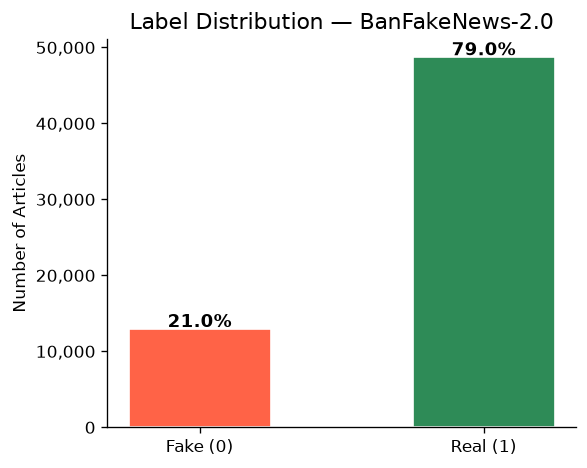

In [4]:
counts = df['label'].value_counts().sort_index()
pcts   = df['label'].value_counts(normalize=True).sort_index().mul(100).round(1)

print(f'Label counts:\n{counts}')
print(f'\nLabel percentages:\n{pcts}')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['Fake (0)', 'Real (1)'],
    [counts.get(0, 0), counts.get(1, 0)],
    color=['tomato', 'seagreen'],
    edgecolor='white', width=0.5
)
for bar, pct in zip(bars, [pcts.get(0, 0), pcts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{pct}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Label Distribution — BanFakeNews-2.0', fontsize=13)
ax.set_ylabel('Number of Articles')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 3 · Word Count Analysis (Raw Content)

In [5]:
df['content'] = df['content'].fillna('').astype(str)
df['word_count'] = df['content'].apply(lambda x: len(x.split()))

print('Overall word count distribution:')
print(df['word_count'].describe().round(1))

Overall word count distribution:
count    61581.0
mean       276.3
std        229.5
min          0.0
25%        142.0
50%        213.0
75%        327.0
max       4788.0
Name: word_count, dtype: float64


In [6]:
print('Word count by label:')
print(df.groupby('label')['word_count'].describe().round(1))

Word count by label:
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      12903.0  273.0  209.3  1.0  149.5  224.0  327.0  3350.0
1      48678.0  277.2  234.6  0.0  141.0  211.0  327.0  4788.0


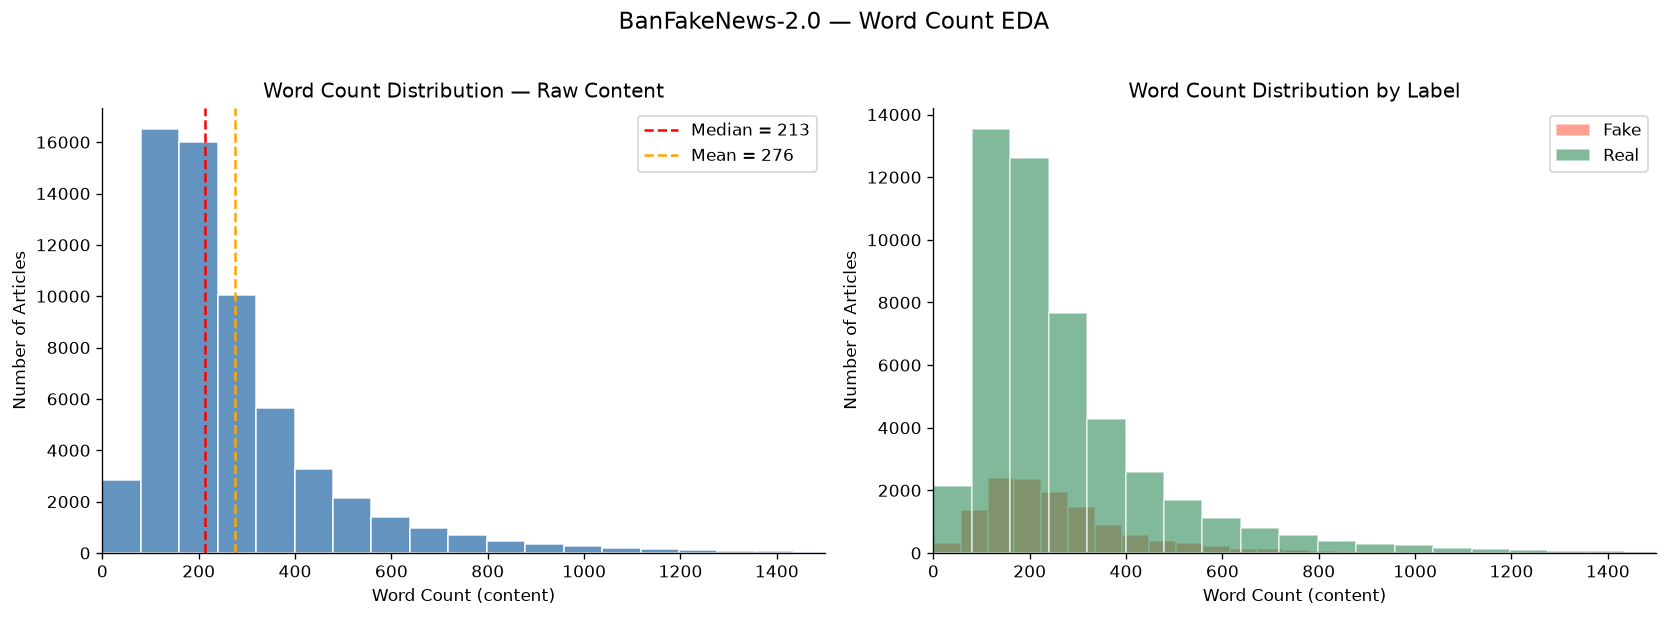

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution
axes[0].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f"Median = {df['word_count'].median():.0f}")
axes[0].axvline(df['word_count'].mean(), color='orange', linestyle='--',
                label=f"Mean = {df['word_count'].mean():.0f}")
axes[0].set_xlabel('Word Count (content)')
axes[0].set_ylabel('Number of Articles')
axes[0].set_title('Word Count Distribution — Raw Content')
axes[0].legend()
axes[0].set_xlim(0, 1500)

# Right: by label
for lbl, color, name in [(0, 'tomato', 'Fake'), (1, 'seagreen', 'Real')]:
    axes[1].hist(df[df['label'] == lbl]['word_count'], bins=60,
                 alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_xlabel('Word Count (content)')
axes[1].set_ylabel('Number of Articles')
axes[1].set_title('Word Count Distribution by Label')
axes[1].legend()
axes[1].set_xlim(0, 1500)

plt.suptitle('BanFakeNews-2.0 — Word Count EDA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Preview the effect of the word-count filter used in preprocessing
MIN_WORDS, MAX_WORDS = 20, 2000
filtered = df[(df['word_count'] >= MIN_WORDS) & (df['word_count'] <= MAX_WORDS)]
removed  = len(df) - len(filtered)
print(f'Articles kept   : {len(filtered):,}  ({len(filtered)/len(df)*100:.1f}%)')
print(f'Articles removed: {removed:,}  (word count < {MIN_WORDS} or > {MAX_WORDS})')

Articles kept   : 61,335  (99.6%)
Articles removed: 246  (word count < 20 or > 2000)


## 4 · Tokenizer Fertility

Fertility = tokens per word.  
Lower is better (means the tokenizer is more efficient for Bangla).

> Downloads `csebuetnlp/banglabert` (~900 MB) on first run.

In [11]:
from transformers import AutoTokenizer

TOKENIZER_NAME = 'csebuetnlp/banglabert'
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
print(f'Vocabulary size  : {tokenizer.vocab_size:,}')

Vocabulary size  : 32,000


Mean fertility : 1.31 tokens/word
→ Excellent — very efficient for Bangla


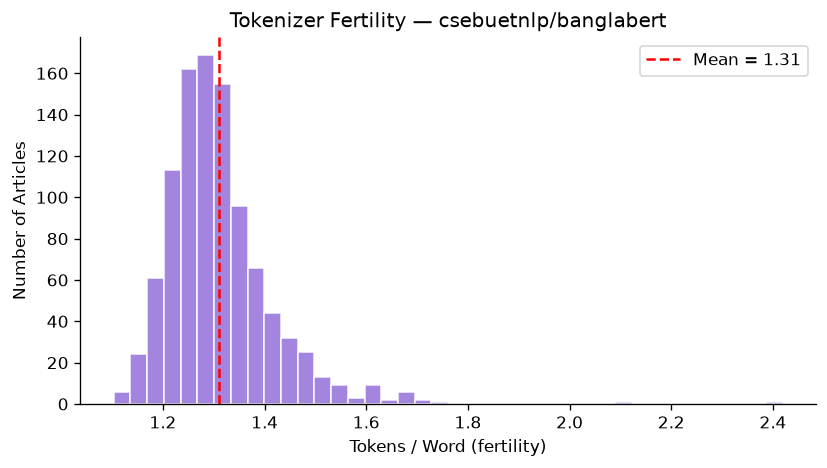

In [12]:
SEED = 42
sample_texts = df['content'].dropna().sample(1000, random_state=SEED).tolist()

fertilities = []
for text in sample_texts:
    words  = len(text.split())
    tokens = len(tokenizer.encode(text, add_special_tokens=False))
    if words > 0:
        fertilities.append(tokens / words)

mean_f = np.mean(fertilities)
print(f'Mean fertility : {mean_f:.2f} tokens/word')

if mean_f < 2.5:
    print('→ Excellent — very efficient for Bangla')
elif mean_f < 3.0:
    print('→ Good — within acceptable range (< 3.0)')
elif mean_f < 4.0:
    print('→ Moderate — borderline, thesis argument still holds')
else:
    print('→ High (> 4.0) — consider switching tokenizer')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fertilities, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(mean_f, color='red', linestyle='--', label=f'Mean = {mean_f:.2f}')
ax.set_xlabel('Tokens / Word (fertility)')
ax.set_ylabel('Number of Articles')
ax.set_title(f'Tokenizer Fertility — {TOKENIZER_NAME}')
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Context-Window Coverage

**Key thesis figure**: how much of each article can BanglaBERT (512 tokens) vs Mamba (768 tokens) read without truncation?

In [13]:
# Use a 2000-article sample for speed; set FULL_DATASET = True for exact numbers
FULL_DATASET = False
SAMPLE_N     = 2000

sample_df = df.copy() if FULL_DATASET else df.sample(SAMPLE_N, random_state=SEED).copy()

print(f'Tokenizing {len(sample_df):,} articles...')
sample_df['token_count'] = sample_df['content'].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True,
                                   max_length=2000, truncation=True))
)
print(sample_df['token_count'].describe().round(1))

Tokenizing 2,000 articles...
count    2000.0
mean      357.3
std       274.8
min        13.0
25%       190.8
50%       276.0
75%       424.0
max      2000.0
Name: token_count, dtype: float64


In [15]:
pct_fit  = (sample_df['token_count'] <= 512).mean() * 100
pct_512  = (sample_df['token_count'] >  512).mean() * 100
pct_768  = (sample_df['token_count'] >  768).mean() * 100
pct_1024 = (sample_df['token_count'] > 1024).mean() * 100

print(f'Fit in BanglaBERT-512  (≤ 512 tokens) : {pct_fit:.1f}%')
print(f'Truncated by BanglaBERT (> 512 tokens) : {pct_512:.1f}%')
print(f'Truncated by Mamba-768  (> 768 tokens) : {pct_768:.1f}%')
print(f'Exceed 1024 tokens                     : {pct_1024:.1f}%')

Fit in BanglaBERT-512  (≤ 512 tokens) : 82.0%
Truncated by BanglaBERT (> 512 tokens) : 17.9%
Truncated by Mamba-768  (> 768 tokens) : 7.2%
Exceed 1024 tokens                     : 3.5%


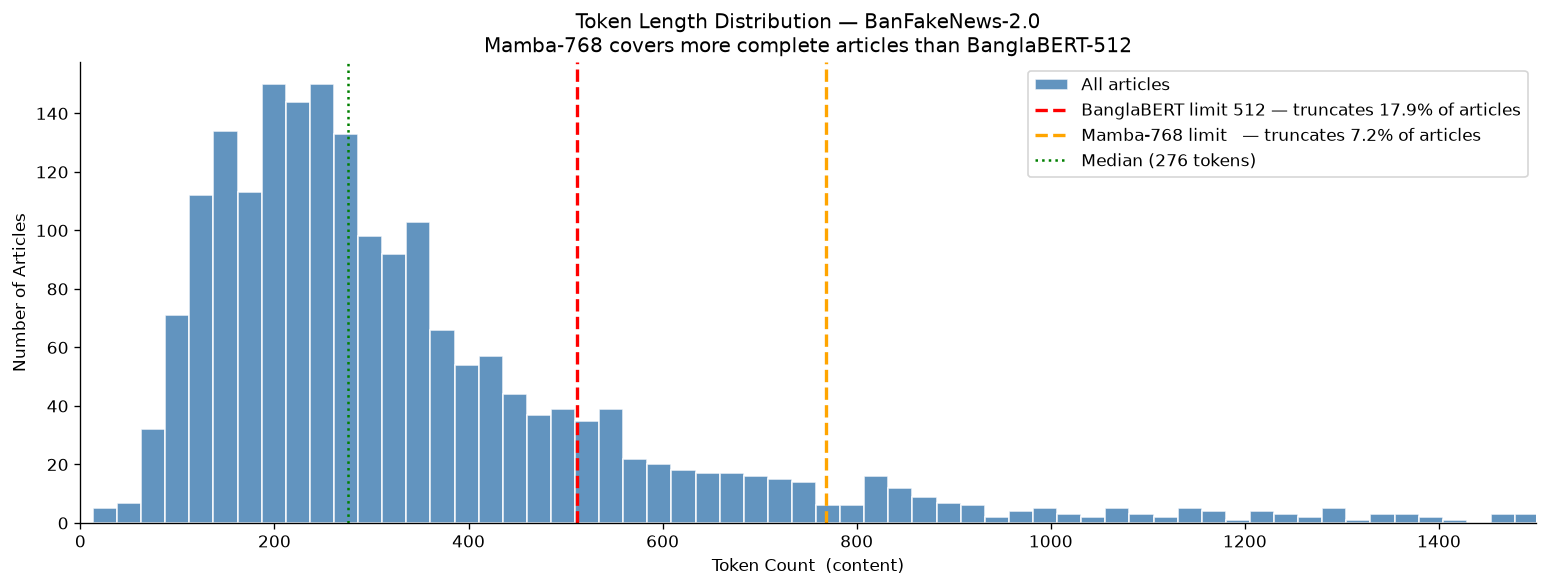

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(sample_df['token_count'], bins=80, color='steelblue',
        edgecolor='white', alpha=0.85, label='All articles')
ax.axvline(512, color='red', linestyle='--', linewidth=2,
           label=f'BanglaBERT limit 512 — truncates {pct_512:.1f}% of articles')
ax.axvline(768, color='orange', linestyle='--', linewidth=2,
           label=f'Mamba-768 limit   — truncates {pct_768:.1f}% of articles')
ax.axvline(sample_df['token_count'].median(), color='green',
           linestyle=':', linewidth=1.5,
           label=f"Median ({sample_df['token_count'].median():.0f} tokens)")
ax.set_xlabel('Token Count  (content)')
ax.set_ylabel('Number of Articles')
ax.set_title(
    'Token Length Distribution — BanFakeNews-2.0\n'
    'Mamba-768 covers more complete articles than BanglaBERT-512'
)
ax.legend(fontsize=10)
ax.set_xlim(0, 1500)
plt.tight_layout()
plt.show()

Token count by label:
        count   mean    std   min    25%    50%    75%     max
label                                                         
0       420.0  351.5  266.0  33.0  192.0  276.5  419.0  1776.0
1      1580.0  358.8  277.2  13.0  190.0  276.0  426.5  2000.0


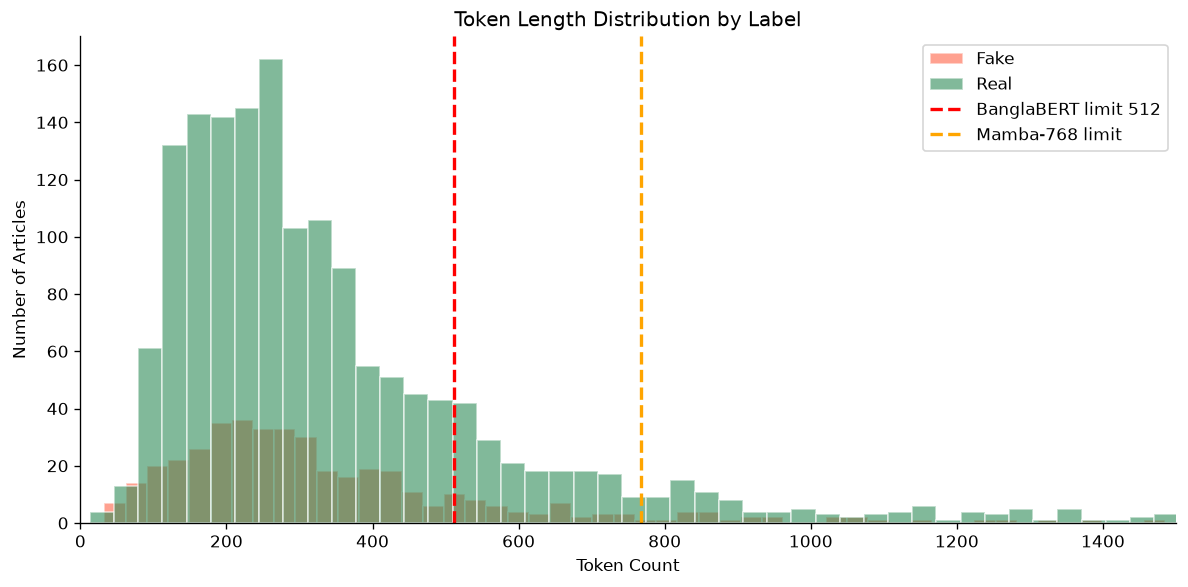

In [17]:
print('Token count by label:')
print(sample_df.groupby('label')['token_count'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for lbl, color, name in [(0, 'tomato', 'Fake'), (1, 'seagreen', 'Real')]:
    ax.hist(sample_df[sample_df['label'] == lbl]['token_count'], bins=60,
            alpha=0.6, color=color, label=name, edgecolor='white')
ax.axvline(512, color='red',    linestyle='--', linewidth=2, label='BanglaBERT limit 512')
ax.axvline(768, color='orange', linestyle='--', linewidth=2, label='Mamba-768 limit')
ax.set_xlabel('Token Count')
ax.set_ylabel('Number of Articles')
ax.set_title('Token Length Distribution by Label')
ax.legend(fontsize=10)
ax.set_xlim(0, 1500)
plt.tight_layout()
plt.show()